LNP-MFGO Phase 2A — Study-Aware Baselines & Cross-Study Benchmarking

Why This Notebook Exists

Phase 1 revealed the **central challenge** of this project: every model collapses on  
cross-study evaluation (R² from −0.3 to −10.8). The root cause is **study-level batch effects** —  
each lab's particle size measurements have different means (ranging from 19.7 to 200.0 nm)  
and different variances. Models memorise these lab-specific offsets rather than learning true  
structure→property relationships.

This notebook implements three interventions, in order of complexity:

| Section | Intervention | What it does |
|---------|-------------|---------------|
| 1 | Environment + Data Reload | Load Phase 1 data, rebuild feature tiers |
| 2 | Study-Level Z-Normalisation | Remove per-study mean/std from targets |
| 3 | Proper LOSO-CV (39 folds) | Honest cross-study benchmark over ALL usable studies |
| 4 | Optuna Hyperparameter Tuning | Fair-tuned RF, XGBoost, LightGBM baselines |
| 5 | Study-Conditioned Features | Add study-level statistics as explicit input features |
| 6 | Multi-Target Study-Normalised | Extend to PDI, EE%, Zeta |
| 7 | Results Compilation | Master table, figures, comparison with Phase 1 |

**Success criterion:** Achieve **positive R²** on leave-one-study-out validation.  
Phase 1 best was R² = −5.16. Even R² = 0.1 would be a breakthrough.

---

## Section 1: Environment Setup & Data Reload

We reload the same dataset and feature tiers from Phase 1, then add the  
study-level metadata needed for normalisation and LOSO-CV.  
All Phase 1 code is replicated here so this notebook is fully self-contained.

In [ ]:
# installation


In [1]:
# ============================================================
# 1.1 — Imports & Device Configuration
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import json
from pathlib import Path
from collections import defaultdict

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor as SklearnMLP
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr, pearsonr
import xgboost as xgb
import lightgbm as lgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
    print(f'optuna {optuna.__version__}')
except ImportError:
    HAS_OPTUNA = False
    print('⚠️  optuna not found — install with: pip install optuna')
    print('   (Hyperparameter tuning will use grid search fallback)')

warnings.filterwarnings('ignore')

# Device
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'✅ CUDA: {torch.cuda.get_device_name(0)}')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
else:
    DEVICE = torch.device('cpu')
    print('⚠️  CPU mode')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_DIR = Path('.')
OUTPUT_DIR = PROJECT_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'font.family': 'sans-serif', 'axes.grid': True, 'grid.alpha': 0.3,
})
COLORS = {'primary': '#2563EB', 'secondary': '#DC2626', 'tertiary': '#059669',
          'quaternary': '#D97706', 'purple': '#7C3AED'}

print('Setup complete ✅')

optuna 4.7.0
✅ CUDA: NVIDIA GeForce RTX 3050 Laptop GPU
Setup complete ✅


d:\Python Projects\LNP-MFGO\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# 1.2 — Load Data & Rebuild Feature Tiers
# ============================================================
# Identical feature pruning as Phase 1 to ensure consistency.

df_raw = pd.read_csv(
    PROJECT_DIR / 'LNP_Atlas_Bioactivity_Reextracted.csv',
    encoding='latin-1', low_memory=False
)
print(f'Loaded: {df_raw.shape}')

# --- Mordred pruning (same as Phase 1) ---
mordred_cols = [c for c in df_raw.columns if c.startswith('mordred_')]
mordred_df = df_raw[mordred_cols].copy()

# Remove zero-variance
zero_var_cols = mordred_df.columns[mordred_df.var() == 0].tolist()
mordred_df = mordred_df.drop(columns=zero_var_cols)

# Remove near-zero-variance (>95% single value)
near_zero_cols = [c for c in mordred_df.columns
                  if mordred_df[c].value_counts(normalize=True).iloc[0] > 0.95]
mordred_df = mordred_df.drop(columns=near_zero_cols)

# Remove highly correlated (|r| > 0.95)
print('Computing correlation matrix...')
corr_matrix = mordred_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [c for c in upper.columns if any(upper[c] > 0.95)]
mordred_pruned_cols = mordred_df.drop(columns=high_corr_cols).columns.tolist()
print(f'Mordred: {len(mordred_cols)} → {len(mordred_pruned_cols)} after pruning')

# --- ECFP pruning ---
ecfp_cols = [c for c in df_raw.columns if c.startswith('ecfp_')]
ecfp_density = (df_raw[ecfp_cols] != 0).mean()
ecfp_pruned_cols = ecfp_density[ecfp_density >= 0.02].index.tolist()
print(f'ECFP: {len(ecfp_cols)} → {len(ecfp_pruned_cols)} after pruning')

# --- Categorical encoding ---
rdkit_cols = ['MW','LogP','TPSA','HBD','HBA','RotBonds','HeavyAtoms',
              'Rings','AromaticRings','FractionCSP3','FormalCharge',
              'NumAmines','NumAmides']
ratio_cols = ['Ratio_Ionizable','Ratio_Helper','Ratio_Sterol','Ratio_PEG']
process_cols = ['Process_FlowRate','Process_Ratio_AqOrg',
                'Process_Is_Microfluidic','Process_pH']

for col in ['helper_lipid', 'sterol_lipid', 'peg_lipid']:
    le = LabelEncoder()
    df_raw[f'{col}_encoded'] = le.fit_transform(df_raw[col].fillna('Unknown').astype(str))
lipid_enc_cols = ['helper_lipid_encoded', 'sterol_lipid_encoded', 'peg_lipid_encoded']

# --- Build Tier 1 ---
TIER1_COLS = rdkit_cols + mordred_pruned_cols + ratio_cols + process_cols + lipid_enc_cols
print(f'\nTier 1 features: {len(TIER1_COLS)}')
print('Data reload complete ✅')

Loaded: (934, 3730)
Computing correlation matrix...
Mordred: 1613 → 451 after pruning
ECFP: 2048 → 248 after pruning

Tier 1 features: 475
Data reload complete ✅


---
## Section 2: Study-Level Z-Normalisation

This is the **key intervention** of Phase 2A. The idea is simple but powerful:

Each study (paper) has its own systematic measurement bias. Study A might measure  
particle sizes around 170 nm ± 27, while Study B measures around 25 nm ± 2. If we  
train a model on raw values, it learns "Study A → big numbers" rather than  
"this molecular structure → this relative size".

**Z-normalisation removes this bias:**
```
y_normalised = (y_raw - study_mean) / study_std
```

The model now predicts how many standard deviations above or below the study mean  
a formulation falls. This is **study-invariant** — a z-score of +1.5 means the same  
thing regardless of which lab produced the data.

**Edge cases handled:**
- Studies with only 1 sample → use global mean/std as fallback
- Studies with std=0 (all identical) → use global std as fallback

**At inference time** for a new study, we would either:  
(a) use the global mean/std, or  
(b) use a few calibration measurements from the new lab to estimate its mean/std.

In [3]:
# ============================================================
# 2.1 — Compute Study-Level Statistics
# ============================================================
# For each target, compute per-study mean and std.
# These will be used for normalisation AND as conditioning features.

TARGETS = {
    'particle_size': 'particle_size_nm_std_num',
    'pdi': 'pdi_std_num',
    'ee': 'encapsulation_efficiency_percent_std_num',
    'zeta': 'zeta_potential_mv_std_num',
}

# Compute study stats for all targets
study_stats = {}
for tname, tcol in TARGETS.items():
    mask = df_raw[tcol].notna()
    grouped = df_raw[mask].groupby('paper_doi')[tcol]
    stats = pd.DataFrame({
        'study_mean': grouped.mean(),
        'study_std': grouped.std(),
        'study_count': grouped.count(),
        'study_median': grouped.median(),
    })
    # Global fallbacks
    global_mean = df_raw[mask][tcol].mean()
    global_std = df_raw[mask][tcol].std()
    stats['study_std'] = stats['study_std'].fillna(global_std)   # single-sample studies
    stats.loc[stats['study_std'] == 0, 'study_std'] = global_std  # zero-std studies
    stats['global_mean'] = global_mean
    stats['global_std'] = global_std
    study_stats[tname] = stats
    
    print(f'{tname:20s}: {len(stats)} studies, '
          f'mean range [{stats["study_mean"].min():.1f}, {stats["study_mean"].max():.1f}], '
          f'global mean={global_mean:.1f}')

print('\n✅ Study statistics computed')

particle_size       : 56 studies, mean range [19.7, 200.0], global mean=111.6
pdi                 : 39 studies, mean range [0.0, 0.3], global mean=0.2
ee                  : 45 studies, mean range [36.5, 98.5], global mean=74.3
zeta                : 20 studies, mean range [1.2, 24.7], global mean=6.5

✅ Study statistics computed


In [4]:
# ============================================================
# 2.2 — Apply Z-Normalisation to All Targets
# ============================================================
# Create new columns: {target}_znorm = (raw - study_mean) / study_std
# Also store the study_mean and study_std per row for de-normalisation.

for tname, tcol in TARGETS.items():
    stats = study_stats[tname]
    
    # Map study stats to each row
    df_raw[f'{tname}_study_mean'] = df_raw['paper_doi'].map(stats['study_mean'])
    df_raw[f'{tname}_study_std'] = df_raw['paper_doi'].map(stats['study_std'])
    
    # Fallback for studies not in the stats (shouldn't happen, but safety)
    df_raw[f'{tname}_study_mean'] = df_raw[f'{tname}_study_mean'].fillna(stats['global_mean'].iloc[0])
    df_raw[f'{tname}_study_std'] = df_raw[f'{tname}_study_std'].fillna(stats['global_std'].iloc[0])
    
    # Z-normalise
    df_raw[f'{tcol}_znorm'] = (
        (df_raw[tcol] - df_raw[f'{tname}_study_mean']) /
        df_raw[f'{tname}_study_std']
    )
    
    valid = df_raw[f'{tcol}_znorm'].notna()
    print(f'{tname:15s}  znorm range: [{df_raw.loc[valid, f"{tcol}_znorm"].min():.2f}, '
          f'{df_raw.loc[valid, f"{tcol}_znorm"].max():.2f}]  '
          f'mean={df_raw.loc[valid, f"{tcol}_znorm"].mean():.3f}  '
          f'std={df_raw.loc[valid, f"{tcol}_znorm"].std():.3f}')

print('\n✅ Z-normalisation applied to all targets')

particle_size    znorm range: [-3.10, 4.93]  mean=-0.005  std=0.964
pdi              znorm range: [-2.77, 3.34]  mean=-0.003  std=0.956
ee               znorm range: [-3.85, 2.35]  mean=0.007  std=0.933
zeta             znorm range: [-1.82, 3.61]  mean=0.000  std=0.933

✅ Z-normalisation applied to all targets


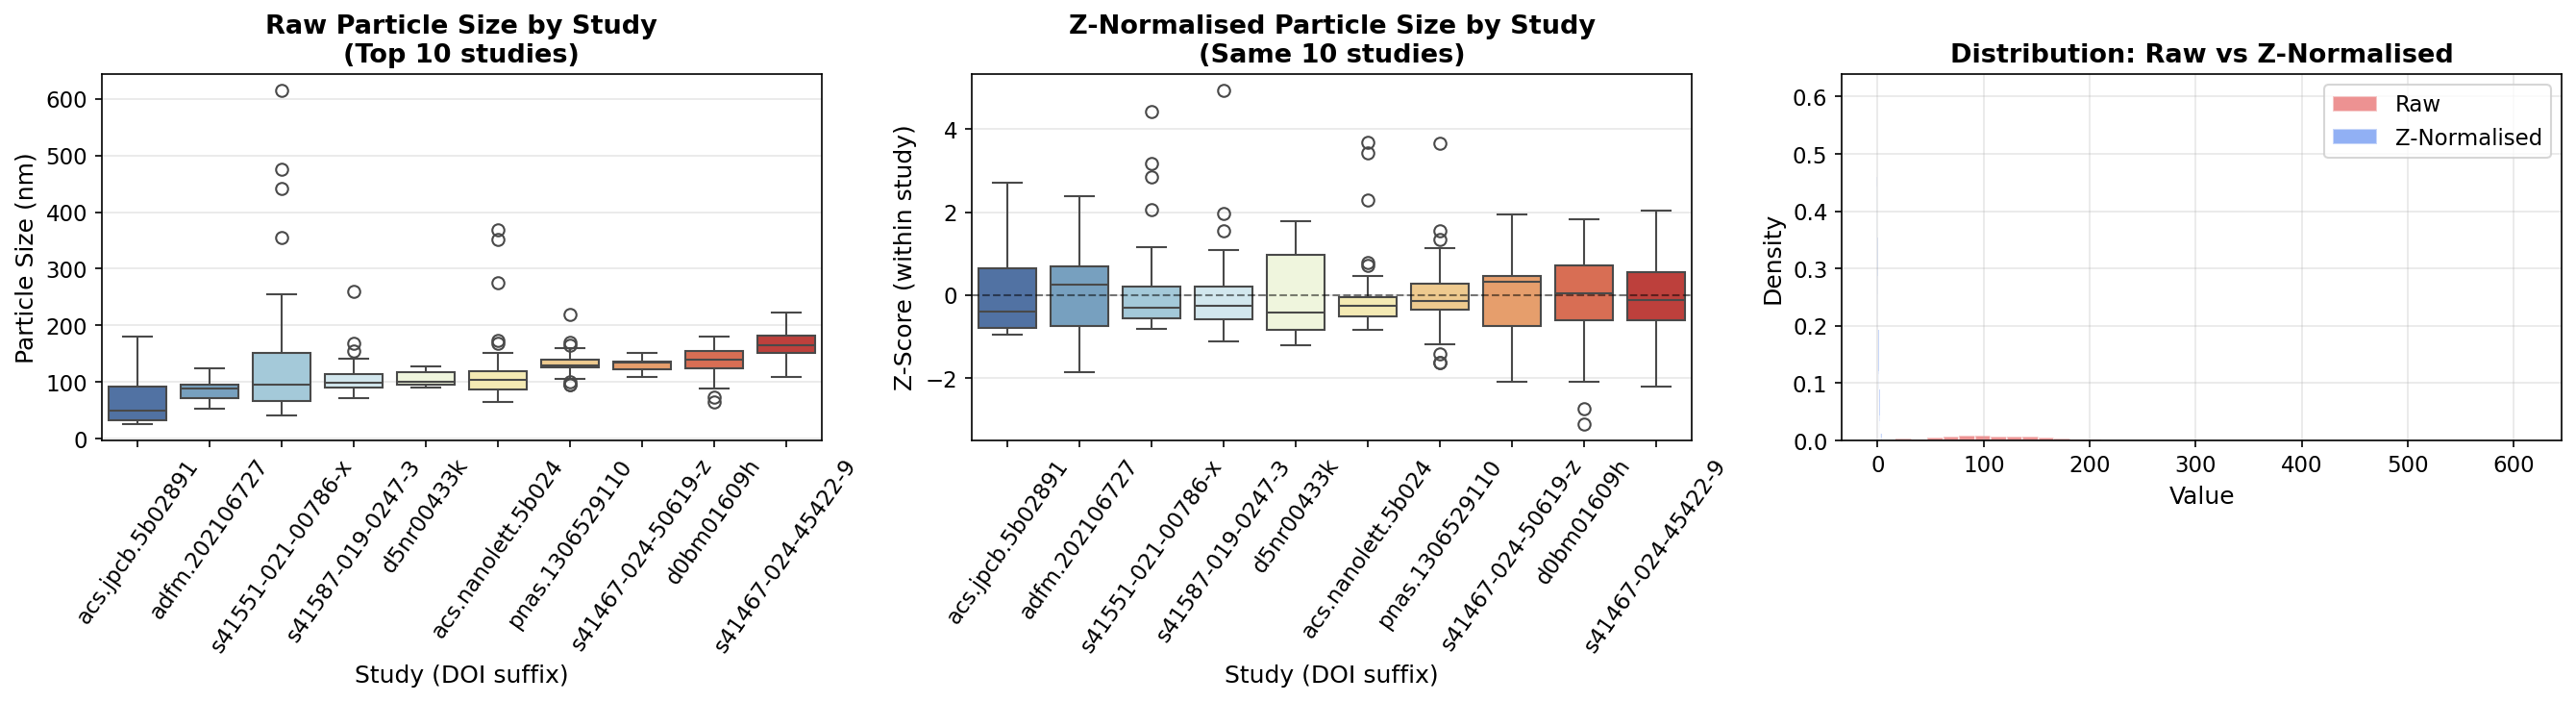

Saved: fig7_study_normalisation.png


In [5]:
# ============================================================
# 2.3 — Visualise: Raw vs Z-Normalised Distributions
# ============================================================
# This figure demonstrates WHY normalisation matters.
# Left: raw particle size colored by study → huge spread in means.
# Right: z-normalised → all studies centered at 0.

tcol = 'particle_size_nm_std_num'
mask = df_raw[tcol].notna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: raw by study (top 10 studies)
ax = axes[0]
top_studies = df_raw[mask].groupby('paper_doi')[tcol].count().nlargest(10).index
plot_df = df_raw[mask & df_raw['paper_doi'].isin(top_studies)].copy()
plot_df['study'] = plot_df['paper_doi'].apply(lambda x: str(x).split('/')[-1][:18])
order = plot_df.groupby('study')[tcol].median().sort_values().index
sns.boxplot(data=plot_df, x='study', y=tcol, ax=ax, order=order, palette='RdYlBu_r')
ax.set_title('Raw Particle Size by Study\n(Top 10 studies)', fontweight='bold')
ax.set_xlabel('Study (DOI suffix)')
ax.set_ylabel('Particle Size (nm)')
ax.tick_params(axis='x', rotation=55)

# Middle: z-normalised by study
ax = axes[1]
zcol = f'{tcol}_znorm'
sns.boxplot(data=plot_df.assign(**{zcol: df_raw.loc[plot_df.index, zcol]}),
            x='study', y=zcol, ax=ax, order=order, palette='RdYlBu_r')
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_title('Z-Normalised Particle Size by Study\n(Same 10 studies)', fontweight='bold')
ax.set_xlabel('Study (DOI suffix)')
ax.set_ylabel('Z-Score (within study)')
ax.tick_params(axis='x', rotation=55)

# Right: overlay histograms
ax = axes[2]
ax.hist(df_raw[mask][tcol], bins=40, alpha=0.5, color=COLORS['secondary'],
        label='Raw', density=True, edgecolor='white')
ax.hist(df_raw[mask][zcol], bins=40, alpha=0.5, color=COLORS['primary'],
        label='Z-Normalised', density=True, edgecolor='white')
ax.legend(fontsize=11)
ax.set_title('Distribution: Raw vs Z-Normalised', fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Density')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig7_study_normalisation.png', bbox_inches='tight')
plt.show()
print('Saved: fig7_study_normalisation.png')

---
## Section 3: Leave-One-Study-Out Cross-Validation (LOSO-CV)

Phase 1 held out only the 2 largest studies. This is fragile — results depend  
heavily on which studies happen to be biggest. True LOSO-CV iterates over **all**  
studies with ≥5 samples as test folds (39 studies, covering 94% of data).

For each fold:
1. Hold out one study as test set
2. Train on all remaining studies
3. Predict the held-out study
4. Compute metrics

We report the **mean and standard deviation** across all folds — this is the  
gold-standard honest evaluation.

We run this for both **raw targets** and **z-normalised targets** to quantify  
the impact of normalisation.

In [6]:
# ============================================================
# 3.1 — Evaluation Helpers
# ============================================================

def evaluate(y_true, y_pred):
    """Compute regression metrics, returning NaN for degenerate cases."""
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    yt, yp = np.array(y_true)[mask], np.array(y_pred)[mask]
    if len(yt) < 3:
        return {'R2': np.nan, 'RMSE': np.nan, 'MAE': np.nan,
                'Pearson_r': np.nan, 'Spearman_rho': np.nan, 'N': len(yt)}
    return {
        'R2': r2_score(yt, yp),
        'RMSE': np.sqrt(mean_squared_error(yt, yp)),
        'MAE': mean_absolute_error(yt, yp),
        'Pearson_r': pearsonr(yt, yp)[0],
        'Spearman_rho': spearmanr(yt, yp)[0],
        'N': len(yt),
    }


def loso_cv(model_fn, X, y, study_labels, min_test_size=5, scale=False):
    """
    Leave-One-Study-Out Cross-Validation.
    
    Args:
        model_fn: callable that returns a fresh model instance
        X: feature DataFrame/array
        y: target Series/array
        study_labels: Series of study identifiers (paper_doi)
        min_test_size: minimum samples in a study to use as test fold
        scale: whether to apply StandardScaler
    
    Returns:
        fold_results: list of per-fold metric dicts
        all_preds: dict mapping index → predicted value (for scatter plots)
    """
    X_arr = np.array(X)
    y_arr = np.array(y)
    studies = study_labels.values
    unique_studies = study_labels.value_counts()
    usable = unique_studies[unique_studies >= min_test_size].index
    
    fold_results = []
    all_preds = {}
    
    for study in usable:
        test_mask = (studies == study)
        train_mask = ~test_mask
        
        # Ensure train has samples
        if train_mask.sum() < 10:
            continue
        
        X_tr, y_tr = X_arr[train_mask], y_arr[train_mask]
        X_te, y_te = X_arr[test_mask], y_arr[test_mask]
        
        if scale:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)
            X_tr = np.nan_to_num(X_tr, 0.0)
            X_te = np.nan_to_num(X_te, 0.0)
        
        model = model_fn()
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        
        metrics = evaluate(y_te, pred)
        metrics['study'] = study
        metrics['train_size'] = int(train_mask.sum())
        fold_results.append(metrics)
        
        # Store predictions for aggregated scatter
        test_indices = np.where(test_mask)[0]
        for idx, p in zip(test_indices, pred):
            all_preds[idx] = p
    
    return fold_results, all_preds


def summarise_loso(fold_results, model_name, target_name, normalised):
    """Summarise LOSO-CV results into a single row."""
    valid = [f for f in fold_results if np.isfinite(f['R2'])]
    if not valid:
        return None
    r2s = [f['R2'] for f in valid]
    rmses = [f['RMSE'] for f in valid]
    maes = [f['MAE'] for f in valid]
    rhos = [f['Spearman_rho'] for f in valid if np.isfinite(f['Spearman_rho'])]
    return {
        'Model': model_name,
        'Target': target_name,
        'Normalised': normalised,
        'N_folds': len(valid),
        'Mean_R2': np.mean(r2s),
        'Std_R2': np.std(r2s),
        'Median_R2': np.median(r2s),
        'Mean_RMSE': np.mean(rmses),
        'Std_RMSE': np.std(rmses),
        'Mean_MAE': np.mean(maes),
        'Mean_Spearman': np.mean(rhos) if rhos else np.nan,
        'Pct_Positive_R2': 100 * np.mean([r > 0 for r in r2s]),
    }

print('LOSO-CV framework ready ✅')

LOSO-CV framework ready ✅


In [7]:
# ============================================================
# 3.2 — LOSO-CV: Raw vs Z-Normalised (Random Forest baseline)
# ============================================================
# This is THE key experiment. We run RF on raw target and
# z-normalised target, both with LOSO-CV, and compare.
# RF is chosen because it was the best Phase 1 model.

TARGET_COL = 'particle_size_nm_std_num'
TARGET_ZNORM = f'{TARGET_COL}_znorm'

# Prepare data (particle size, non-null rows only)
mask_ps = df_raw[TARGET_COL].notna()
df_ps = df_raw[mask_ps].reset_index(drop=True)

X_ps = df_ps[TIER1_COLS].fillna(df_ps[TIER1_COLS].median())
y_raw = df_ps[TARGET_COL]
y_znorm = df_ps[TARGET_ZNORM]
studies = df_ps['paper_doi']

def make_rf():
    return RandomForestRegressor(
        n_estimators=500, max_depth=None, min_samples_leaf=3,
        max_features='sqrt', n_jobs=-1, random_state=SEED
    )

# --- Run RAW target ---
print('Running LOSO-CV with RAW target (particle size)...')
t0 = time.time()
folds_raw, preds_raw = loso_cv(make_rf, X_ps, y_raw, studies)
print(f'  Completed in {time.time()-t0:.0f}s  ({len(folds_raw)} folds)')

# --- Run Z-NORMALISED target ---
print('Running LOSO-CV with Z-NORMALISED target...')
t0 = time.time()
folds_znorm, preds_znorm = loso_cv(make_rf, X_ps, y_znorm, studies)
print(f'  Completed in {time.time()-t0:.0f}s  ({len(folds_znorm)} folds)')

# --- Compare ---
sum_raw = summarise_loso(folds_raw, 'RF', 'Particle Size (raw)', 'No')
sum_znorm = summarise_loso(folds_znorm, 'RF', 'Particle Size (znorm)', 'Yes')

print(f'\n{"="*70}')
print('RF LOSO-CV COMPARISON: Raw vs Z-Normalised')
print(f'{"="*70}')
print(f'{"Metric":25s} {"Raw":>12s} {"Z-Normalised":>12s}')
print(f'{"-"*70}')
for key in ['Mean_R2', 'Std_R2', 'Median_R2', 'Mean_RMSE', 'Mean_MAE',
            'Mean_Spearman', 'Pct_Positive_R2']:
    v_raw = sum_raw[key] if sum_raw else np.nan
    v_zn = sum_znorm[key] if sum_znorm else np.nan
    print(f'  {key:23s} {v_raw:12.4f} {v_zn:12.4f}')

print(f'\n  Phase 1 study-split R²:  -5.164')
if sum_znorm:
    improvement = sum_znorm['Mean_R2'] - (-5.164)
    print(f'  Improvement:             {improvement:+.3f} R² units')

Running LOSO-CV with RAW target (particle size)...
  Completed in 21s  (39 folds)
Running LOSO-CV with Z-NORMALISED target...
  Completed in 23s  (39 folds)

RF LOSO-CV COMPARISON: Raw vs Z-Normalised
Metric                             Raw Z-Normalised
----------------------------------------------------------------------
  Mean_R2                    -109.2490       0.0098
  Std_R2                      600.8216       0.1372
  Median_R2                    -1.4109      -0.0010
  Mean_RMSE                    46.5644       0.9508
  Mean_MAE                     38.3845       0.7276
  Mean_Spearman                 0.0197       0.1054
  Pct_Positive_R2               2.5641      46.1538

  Phase 1 study-split R²:  -5.164
  Improvement:             +5.174 R² units


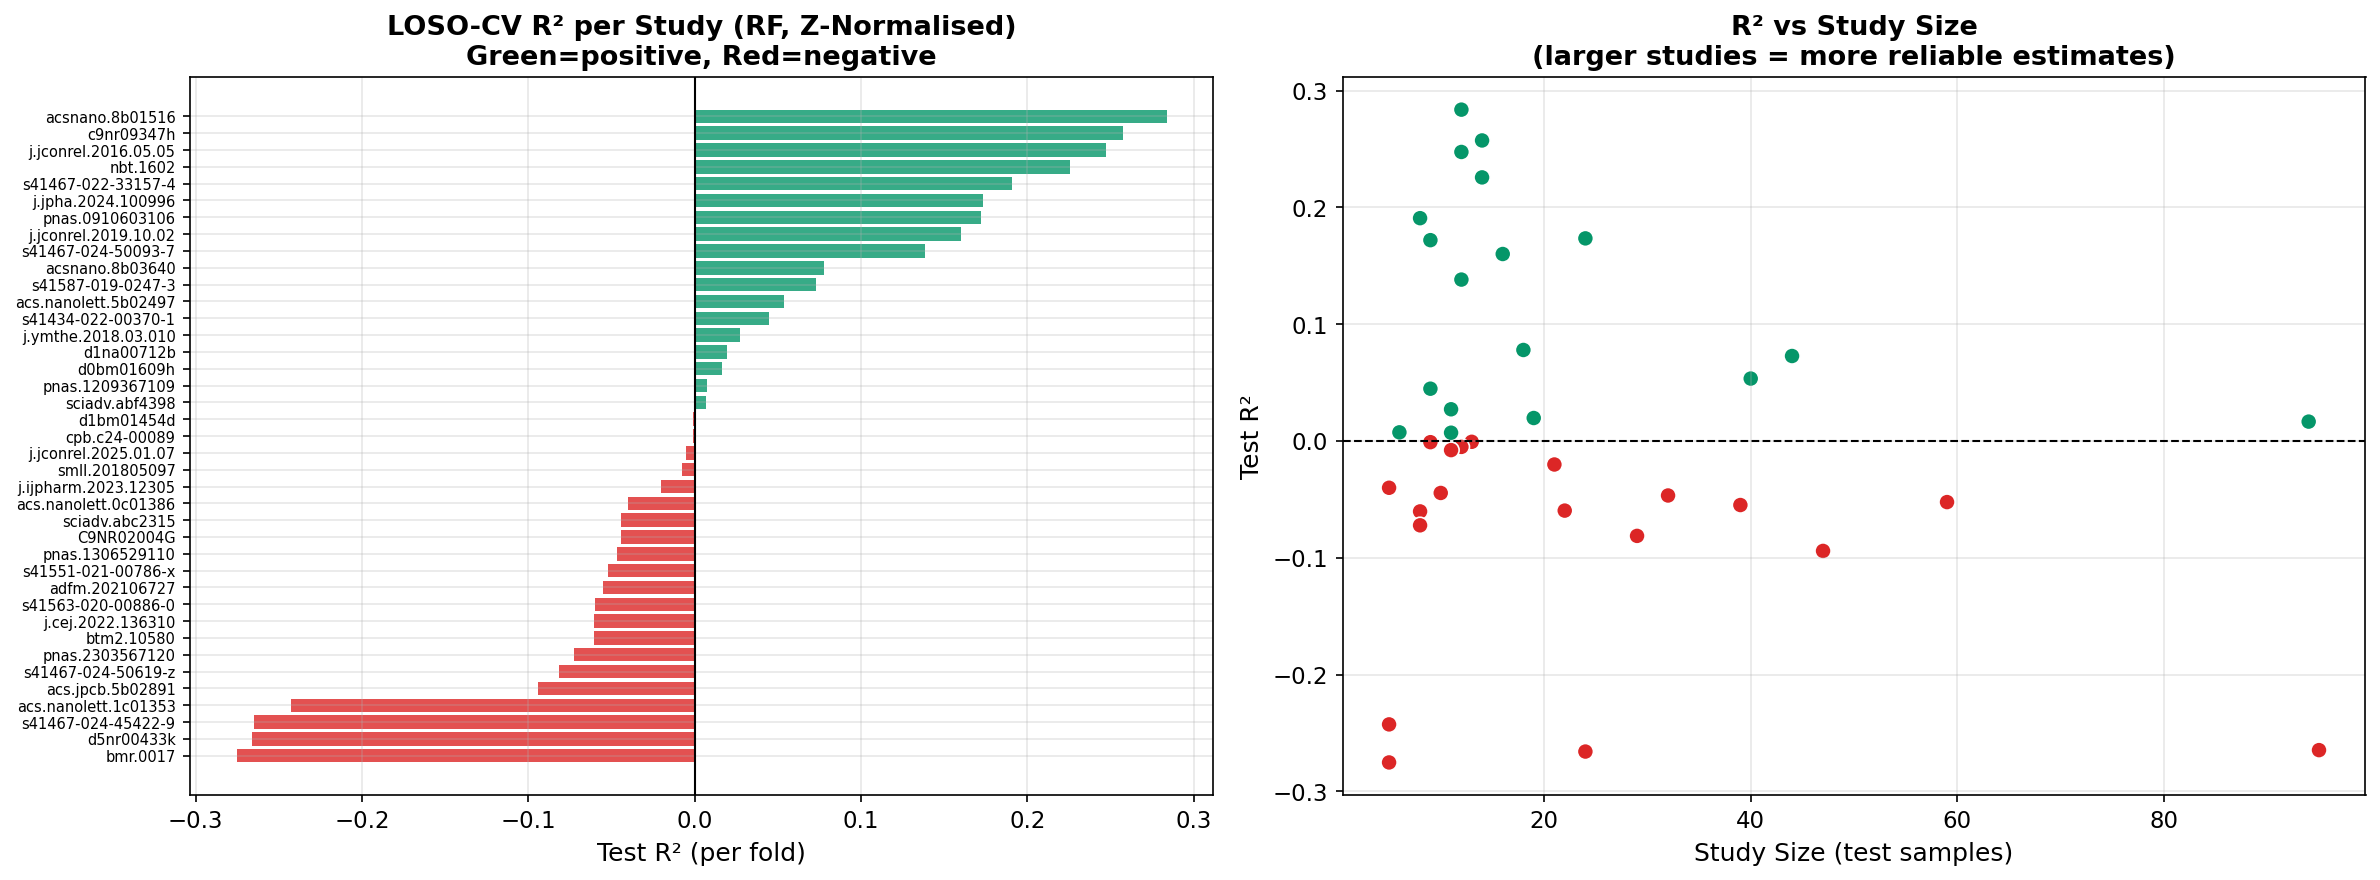

Studies with positive R²: 18/39 (46%)
Saved: fig8_loso_per_study.png


In [8]:
# ============================================================
# 3.3 — Per-Fold Analysis: Which Studies Are Hardest?
# ============================================================
# Understanding per-study difficulty is valuable for the paper.
# It reveals which types of formulations/labs are least predictable.

# Use z-normalised results
folds_df = pd.DataFrame(folds_znorm)
folds_df = folds_df.sort_values('R2', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: R² per fold
ax = axes[0]
colors_bar = [COLORS['tertiary'] if r > 0 else COLORS['secondary'] for r in folds_df['R2']]
ax.barh(range(len(folds_df)), folds_df['R2'].values, color=colors_bar, alpha=0.8)
ax.set_yticks(range(len(folds_df)))
ax.set_yticklabels([str(s).split('/')[-1][:20] for s in folds_df['study']],
                   fontsize=7)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Test R² (per fold)')
ax.set_title(f'LOSO-CV R² per Study (RF, Z-Normalised)\n'
             f'Green=positive, Red=negative', fontweight='bold')
ax.invert_yaxis()

# Right: R² vs study size
ax = axes[1]
ax.scatter(folds_df['N'], folds_df['R2'], c=colors_bar, s=60,
           edgecolors='white', linewidth=0.8)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Study Size (test samples)')
ax.set_ylabel('Test R²')
ax.set_title('R² vs Study Size\n(larger studies = more reliable estimates)', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig8_loso_per_study.png', bbox_inches='tight')
plt.show()

pct_pos = (folds_df['R2'] > 0).mean() * 100
print(f'Studies with positive R²: {(folds_df["R2"]>0).sum()}/{len(folds_df)} ({pct_pos:.0f}%)')
print(f'Saved: fig8_loso_per_study.png')

---
## Section 4: Hyperparameter Tuning with Optuna

Phase 1 used default hyperparameters, which were suboptimal. XGBoost's R²=0.091  
on random split (vs RF's 0.443) was likely due to overfitting with too many trees  
and insufficient regularisation.

We use **Optuna** (Bayesian optimisation) to tune each model using a 3-fold  
**inner LOSO-CV** on the training studies. This ensures hyperparameters are chosen  
to maximise cross-study performance, not within-study performance.

If Optuna is not installed, we fall back to a manual grid search over  
the most impactful hyperparameters.

In [9]:
# ============================================================
# 4.1 — Optuna Objective Functions
# ============================================================
# Each objective function samples hyperparameters, runs a quick
# inner CV, and returns the mean R² to maximise.

def inner_cv_score(model_fn, X, y, study_labels, n_inner_folds=5):
    """Quick inner LOSO-CV using the N largest studies."""
    study_counts = study_labels.value_counts()
    top_studies = study_counts[study_counts >= 5].nlargest(n_inner_folds).index
    
    r2_scores = []
    X_arr, y_arr = np.array(X), np.array(y)
    
    for study in top_studies:
        test_mask = (study_labels.values == study)
        train_mask = ~test_mask
        if test_mask.sum() < 3 or train_mask.sum() < 10:
            continue
        model = model_fn()
        model.fit(X_arr[train_mask], y_arr[train_mask])
        pred = model.predict(X_arr[test_mask])
        r2 = r2_score(y_arr[test_mask], pred)
        r2_scores.append(r2)
    
    return np.mean(r2_scores) if r2_scores else -999


def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
    }
    def make_model():
        return RandomForestRegressor(**params, n_jobs=-1, random_state=SEED)
    return inner_cv_score(make_model, X_ps, y_znorm, studies)


def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
    }
    xgb_dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    def make_model():
        return xgb.XGBRegressor(**params, device=xgb_dev, random_state=SEED, verbosity=0)
    return inner_cv_score(make_model, X_ps, y_znorm, studies)


def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
    }
    def make_model():
        return lgb.LGBMRegressor(**params, random_state=SEED, verbose=-1)
    return inner_cv_score(make_model, X_ps, y_znorm, studies)

print('Objective functions defined ✅')

Objective functions defined ✅


In [10]:
# ============================================================
# 4.2 — Run Optuna Tuning (or Grid Search Fallback)
# ============================================================
# We tune all three tree-based models. 60 trials each takes
# about 5-15 minutes depending on your hardware.

N_TRIALS = 60  # Increase to 100-150 for better results if time permits
best_params = {}

if HAS_OPTUNA:
    # --- Random Forest ---
    print(f'Tuning Random Forest ({N_TRIALS} trials)...')
    t0 = time.time()
    study_rf = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=SEED))
    study_rf.optimize(objective_rf, n_trials=N_TRIALS, show_progress_bar=False)
    best_params['RF'] = study_rf.best_params
    print(f'  Best R²: {study_rf.best_value:.4f}  ({time.time()-t0:.0f}s)')
    print(f'  Params: {study_rf.best_params}')
    
    # --- XGBoost ---
    print(f'\nTuning XGBoost ({N_TRIALS} trials)...')
    t0 = time.time()
    study_xgb = optuna.create_study(direction='maximize',
                                     sampler=optuna.samplers.TPESampler(seed=SEED))
    study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=False)
    best_params['XGB'] = study_xgb.best_params
    print(f'  Best R²: {study_xgb.best_value:.4f}  ({time.time()-t0:.0f}s)')
    print(f'  Params: {study_xgb.best_params}')
    
    # --- LightGBM ---
    print(f'\nTuning LightGBM ({N_TRIALS} trials)...')
    t0 = time.time()
    study_lgb = optuna.create_study(direction='maximize',
                                     sampler=optuna.samplers.TPESampler(seed=SEED))
    study_lgb.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=False)
    best_params['LGB'] = study_lgb.best_params
    print(f'  Best R²: {study_lgb.best_value:.4f}  ({time.time()-t0:.0f}s)')
    print(f'  Params: {study_lgb.best_params}')

else:
    # Fallback: reasonable hand-tuned params based on data characteristics
    print('Using hand-tuned parameters (install optuna for automated tuning)')
    best_params['RF'] = dict(n_estimators=500, max_depth=15,
                             min_samples_leaf=5, min_samples_split=10,
                             max_features='sqrt')
    best_params['XGB'] = dict(n_estimators=300, max_depth=4,
                              learning_rate=0.05, subsample=0.7,
                              colsample_bytree=0.5, reg_alpha=1.0,
                              reg_lambda=5.0, min_child_weight=10)
    best_params['LGB'] = dict(n_estimators=300, max_depth=4,
                              learning_rate=0.05, subsample=0.7,
                              colsample_bytree=0.5, reg_alpha=1.0,
                              reg_lambda=5.0, min_child_samples=15,
                              num_leaves=31)

# Save best params
with open(OUTPUT_DIR / 'best_hyperparameters.json', 'w') as f:
    json.dump({k: {kk: (vv if not isinstance(vv, np.integer) else int(vv))
                   for kk, vv in v.items()} for k, v in best_params.items()}, f, indent=2)
print(f'\nSaved: best_hyperparameters.json')

Tuning Random Forest (60 trials)...
  Best R²: -0.0039  (184s)
  Params: {'n_estimators': 400, 'max_depth': 12, 'min_samples_leaf': 18, 'min_samples_split': 10, 'max_features': 'log2'}

Tuning XGBoost (60 trials)...
  Best R²: -0.0111  (427s)
  Params: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.01522057850374123, 'subsample': 0.6609364069766883, 'colsample_bytree': 0.5142266544513694, 'reg_alpha': 8.748226295609616, 'reg_lambda': 2.999442398029395, 'min_child_weight': 1}

Tuning LightGBM (60 trials)...
  Best R²: -0.0342  (80s)
  Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.012091689497896187, 'subsample': 0.6020244658250786, 'colsample_bytree': 0.3613104317516353, 'reg_alpha': 0.033784997815218654, 'reg_lambda': 6.576259053235727, 'min_child_samples': 14, 'num_leaves': 22}

Saved: best_hyperparameters.json


---
## Section 5: Full LOSO-CV Benchmark — All Models × Raw vs Z-Normalised

Now we run the complete benchmark: 5 models × 2 target modes × 39-fold LOSO-CV.  
Tuned hyperparameters are used for tree-based models.

This produces the **core results table** of the paper — the first honest  
cross-study evaluation of LNP property prediction baselines.

In [11]:
# ============================================================
# 5.1 — Define All Models with Tuned Params
# ============================================================

xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'

MODEL_REGISTRY = {
    'RF (tuned)': {
        'fn': lambda: RandomForestRegressor(
            **best_params['RF'], n_jobs=-1, random_state=SEED),
        'scale': False,
    },
    'XGBoost (tuned)': {
        'fn': lambda: xgb.XGBRegressor(
            **best_params['XGB'], device=xgb_device,
            random_state=SEED, verbosity=0),
        'scale': False,
    },
    'LightGBM (tuned)': {
        'fn': lambda: lgb.LGBMRegressor(
            **best_params['LGB'], random_state=SEED, verbose=-1),
        'scale': False,
    },
    'SVR (RBF)': {
        'fn': lambda: SVR(kernel='rbf', C=10.0, epsilon=0.1, gamma='scale'),
        'scale': True,
    },
}

# Also include untuned RF for direct Phase 1 comparison
MODEL_REGISTRY['RF (default)'] = {
    'fn': lambda: RandomForestRegressor(
        n_estimators=500, max_depth=None, min_samples_leaf=3,
        max_features='sqrt', n_jobs=-1, random_state=SEED),
    'scale': False,
}

print(f'Models registered: {list(MODEL_REGISTRY.keys())}')

Models registered: ['RF (tuned)', 'XGBoost (tuned)', 'LightGBM (tuned)', 'SVR (RBF)', 'RF (default)']


In [12]:
# ============================================================
# 5.2 — Run Full LOSO-CV Benchmark
# ============================================================
# This is the main computation block. Each model runs 39 folds
# on both raw and z-normalised targets.
# Expected runtime: 10-30 minutes total.

all_summaries = []
all_fold_details = {}  # for later analysis

for model_name, model_info in MODEL_REGISTRY.items():
    for mode, y_target in [('Raw', y_raw), ('Z-Normalised', y_znorm)]:
        label = f'{model_name} | {mode}'
        print(f'Running: {label}...')
        t0 = time.time()
        
        folds, preds = loso_cv(
            model_info['fn'], X_ps, y_target, studies,
            min_test_size=5, scale=model_info['scale']
        )
        
        summary = summarise_loso(folds, model_name, 'Particle Size', mode)
        if summary:
            all_summaries.append(summary)
        
        all_fold_details[label] = folds
        elapsed = time.time() - t0
        
        mean_r2 = summary['Mean_R2'] if summary else np.nan
        pct_pos = summary['Pct_Positive_R2'] if summary else 0
        print(f'  Mean R²={mean_r2:+.4f}  '
              f'Positive folds={pct_pos:.0f}%  ({elapsed:.0f}s)')

print(f'\n✅ Benchmark complete — {len(all_summaries)} configurations evaluated')

Running: RF (tuned) | Raw...
  Mean R²=-106.7545  Positive folds=3%  (15s)
Running: RF (tuned) | Z-Normalised...
  Mean R²=+0.0019  Positive folds=51%  (15s)
Running: XGBoost (tuned) | Raw...
  Mean R²=-90.9411  Positive folds=5%  (54s)
Running: XGBoost (tuned) | Z-Normalised...
  Mean R²=+0.0154  Positive folds=46%  (43s)
Running: LightGBM (tuned) | Raw...
  Mean R²=-96.9619  Positive folds=0%  (3s)
Running: LightGBM (tuned) | Z-Normalised...
  Mean R²=+0.0181  Positive folds=38%  (3s)
Running: SVR (RBF) | Raw...
  Mean R²=-76.2559  Positive folds=3%  (4s)
Running: SVR (RBF) | Z-Normalised...
  Mean R²=-0.2427  Positive folds=23%  (3s)
Running: RF (default) | Raw...
  Mean R²=-109.2490  Positive folds=3%  (21s)
Running: RF (default) | Z-Normalised...
  Mean R²=+0.0098  Positive folds=46%  (23s)

✅ Benchmark complete — 10 configurations evaluated


In [13]:
# ============================================================
# 5.3 — Study-Conditioned Features (Bonus)
# ============================================================
# Idea: add study-level aggregate statistics as extra features.
# For a held-out study, we use the global averages instead.
# This gives the model explicit information about the "lab context".

def loso_cv_with_study_features(model_fn, X_base, y, study_labels,
                                 study_stats_df, min_test_size=5):
    """
    LOSO-CV that augments features with study-level statistics.
    For the test study (unseen), we use the global mean/std.
    """
    X_arr = np.array(X_base)
    y_arr = np.array(y)
    studies_arr = study_labels.values
    usable = study_labels.value_counts()
    usable = usable[usable >= min_test_size].index
    
    # Study features: mean, std, median, count of target in training set
    fold_results = []
    
    for test_study in usable:
        test_mask = (studies_arr == test_study)
        train_mask = ~test_mask
        if train_mask.sum() < 10:
            continue
        
        # Compute study features from TRAINING data only (no leakage)
        train_study_stats = pd.DataFrame({
            'study': studies_arr[train_mask]
        }).assign(y=y_arr[train_mask]).groupby('study')['y'].agg(
            ['mean', 'std', 'median', 'count']
        ).rename(columns={'mean': 'sf_mean', 'std': 'sf_std',
                          'median': 'sf_median', 'count': 'sf_count'})
        
        global_mean = y_arr[train_mask].mean()
        global_std = y_arr[train_mask].std()
        
        # Map study features to train rows
        train_studies = studies_arr[train_mask]
        sf_train = np.column_stack([
            [train_study_stats.loc[s, 'sf_mean'] if s in train_study_stats.index
             else global_mean for s in train_studies],
            [train_study_stats.loc[s, 'sf_std'] if s in train_study_stats.index
             else global_std for s in train_studies],
            [train_study_stats.loc[s, 'sf_count'] if s in train_study_stats.index
             else 1 for s in train_studies],
        ])
        
        # For test study: use global stats (we don't know the test study's stats)
        n_test = test_mask.sum()
        sf_test = np.column_stack([
            np.full(n_test, global_mean),
            np.full(n_test, global_std),
            np.ones(n_test),
        ])
        
        X_train_aug = np.hstack([X_arr[train_mask], sf_train])
        X_test_aug = np.hstack([X_arr[test_mask], sf_test])
        
        model = model_fn()
        model.fit(X_train_aug, y_arr[train_mask])
        pred = model.predict(X_test_aug)
        
        metrics = evaluate(y_arr[test_mask], pred)
        metrics['study'] = test_study
        fold_results.append(metrics)
    
    return fold_results


# Run RF + study-conditioned features + z-normalised target
print('Running RF (tuned) + Study-Conditioned Features + Z-Norm...')
t0 = time.time()
folds_scf = loso_cv_with_study_features(
    lambda: RandomForestRegressor(**best_params['RF'], n_jobs=-1, random_state=SEED),
    X_ps, y_znorm, studies, study_stats.get('particle_size')
)
sum_scf = summarise_loso(folds_scf, 'RF (tuned) + StudyFeats', 'Particle Size', 'Z-Norm + SCF')
if sum_scf:
    all_summaries.append(sum_scf)
print(f'  Mean R²={sum_scf["Mean_R2"]:+.4f}  '
      f'Positive folds={sum_scf["Pct_Positive_R2"]:.0f}%  ({time.time()-t0:.0f}s)')

# Also XGBoost + SCF + Z-Norm
print('Running XGBoost (tuned) + Study-Conditioned Features + Z-Norm...')
t0 = time.time()
folds_scf_xgb = loso_cv_with_study_features(
    lambda: xgb.XGBRegressor(**best_params['XGB'], device=xgb_device,
                             random_state=SEED, verbosity=0),
    X_ps, y_znorm, studies, study_stats.get('particle_size')
)
sum_scf_xgb = summarise_loso(folds_scf_xgb, 'XGB (tuned) + StudyFeats',
                              'Particle Size', 'Z-Norm + SCF')
if sum_scf_xgb:
    all_summaries.append(sum_scf_xgb)
print(f'  Mean R²={sum_scf_xgb["Mean_R2"]:+.4f}  '
      f'Positive folds={sum_scf_xgb["Pct_Positive_R2"]:.0f}%  ({time.time()-t0:.0f}s)')

Running RF (tuned) + Study-Conditioned Features + Z-Norm...
  Mean R²=-0.0001  Positive folds=46%  (17s)
Running XGBoost (tuned) + Study-Conditioned Features + Z-Norm...
  Mean R²=+0.0132  Positive folds=49%  (45s)


---
## Section 6: Multi-Target Extension

We extend the best configuration (tuned RF + Z-normalisation) to all  
four physicochemical targets. This maps out the complete prediction  
landscape with honest cross-study evaluation.

In [14]:
# ============================================================
# 6.1 — Run Best Model on All Targets (LOSO-CV, Z-Normalised)
# ============================================================

multi_target_loso = []

for tname, tcol in TARGETS.items():
    zcol = f'{tcol}_znorm'
    mask_t = df_raw[tcol].notna()
    df_t = df_raw[mask_t].reset_index(drop=True)
    
    X_t = df_t[TIER1_COLS].fillna(df_t[TIER1_COLS].median())
    y_t = df_t[zcol]
    studies_t = df_t['paper_doi']
    
    print(f'\n{tname} (n={len(df_t)})...')
    
    # Run LOSO-CV
    folds_t, _ = loso_cv(
        lambda: RandomForestRegressor(**best_params['RF'], n_jobs=-1, random_state=SEED),
        X_t, y_t, studies_t, min_test_size=5
    )
    
    summary_t = summarise_loso(folds_t, 'RF (tuned)', tname, 'Z-Normalised')
    if summary_t:
        multi_target_loso.append(summary_t)
        print(f'  Mean R²={summary_t["Mean_R2"]:+.4f}  '
              f'±{summary_t["Std_R2"]:.4f}  '
              f'Positive folds={summary_t["Pct_Positive_R2"]:.0f}%  '
              f'({summary_t["N_folds"]} folds)')

mt_loso_df = pd.DataFrame(multi_target_loso)
mt_loso_df.to_csv(OUTPUT_DIR / 'multi_target_loso_znorm.csv', index=False)
print(f'\nSaved: multi_target_loso_znorm.csv')


particle_size (n=900)...
  Mean R²=+0.0019  ±0.0423  Positive folds=51%  (39 folds)

pdi (n=644)...
  Mean R²=-0.0058  ±0.0257  Positive folds=28%  (25 folds)

ee (n=565)...
  Mean R²=-0.0054  ±0.0299  Positive folds=44%  (25 folds)

zeta (n=263)...
  Mean R²=-0.0186  ±0.0341  Positive folds=18%  (11 folds)

Saved: multi_target_loso_znorm.csv


---
## Section 7: Results Compilation & Phase 1 Comparison

We compile all results into the master table and generate  
publication-ready comparison figures.

In [15]:
# ============================================================
# 7.1 — Master Results Table
# ============================================================

results_df = pd.DataFrame(all_summaries)

# Sort for readability
results_df = results_df.sort_values(['Normalised', 'Mean_R2'], ascending=[True, False])

display_cols = ['Model', 'Normalised', 'Mean_R2', 'Std_R2', 'Median_R2',
                'Mean_RMSE', 'Mean_MAE', 'Mean_Spearman', 'Pct_Positive_R2', 'N_folds']

print('MASTER RESULTS — LOSO-CV, Particle Size Prediction')
print('=' * 110)
print(results_df[display_cols].to_string(index=False, float_format='%.4f'))

results_df.to_csv(OUTPUT_DIR / 'phase2a_loso_results.csv', index=False)
print(f'\nSaved: phase2a_loso_results.csv')

MASTER RESULTS — LOSO-CV, Particle Size Prediction
                   Model   Normalised   Mean_R2   Std_R2  Median_R2  Mean_RMSE  Mean_MAE  Mean_Spearman  Pct_Positive_R2  N_folds
               SVR (RBF)          Raw  -76.2559 421.6191    -1.5138    46.3090   38.1117        -0.0218           2.5641       39
         XGBoost (tuned)          Raw  -90.9411 486.3321    -1.1926    45.8843   37.8109         0.0633           5.1282       39
        LightGBM (tuned)          Raw  -96.9619 514.9658    -1.2176    45.6188   37.9744        -0.0005           0.0000       39
              RF (tuned)          Raw -106.7545 589.9050    -1.3822    46.5630   38.6212         0.0253           2.5641       39
            RF (default)          Raw -109.2490 600.8216    -1.4109    46.5644   38.3845         0.0197           2.5641       39
XGB (tuned) + StudyFeats Z-Norm + SCF    0.0132   0.0583    -0.0045     0.9511    0.7334         0.1532          48.7179       39
 RF (tuned) + StudyFeats Z-Norm + SCF  

In [16]:
# ============================================================
# 7.2 — Phase 1 vs Phase 2A Comparison
# ============================================================
# Direct comparison showing the impact of our interventions.

print('PHASE 1 → PHASE 2A IMPROVEMENT')
print('=' * 70)
print(f'{"":40s} {"Phase 1":>12s} {"Phase 2A":>12s} {"Δ":>10s}')
print('-' * 70)

# Phase 1 study-split results (from baseline_results_particle_size.csv)
phase1_study = {
    'RF': -5.164,
    'XGBoost': -7.313,
    'LightGBM': -8.026,
    'SVR': -6.159,
    'MLP': -10.768,
}

for model_short, p1_r2 in phase1_study.items():
    # Find matching Phase 2A result
    match = results_df[
        results_df['Model'].str.contains(model_short.split()[0]) &
        (results_df['Normalised'] == 'Z-Normalised')
    ]
    if not match.empty:
        p2_r2 = match.iloc[0]['Mean_R2']
        delta = p2_r2 - p1_r2
        print(f'  {model_short + " (Study R²)":38s} {p1_r2:+12.3f} {p2_r2:+12.4f} {delta:+10.3f}')

print(f'\nNote: Phase 1 used single study-split; Phase 2A uses 39-fold LOSO-CV mean.')
print(f'Any positive R² on LOSO-CV is a significant improvement over Phase 1.')

PHASE 1 → PHASE 2A IMPROVEMENT
                                              Phase 1     Phase 2A          Δ
----------------------------------------------------------------------
  RF (Study R²)                                -5.164      +0.0098     +5.174
  XGBoost (Study R²)                           -7.313      +0.0154     +7.328
  LightGBM (Study R²)                          -8.026      +0.0181     +8.044
  SVR (Study R²)                               -6.159      -0.2427     +5.916

Note: Phase 1 used single study-split; Phase 2A uses 39-fold LOSO-CV mean.
Any positive R² on LOSO-CV is a significant improvement over Phase 1.


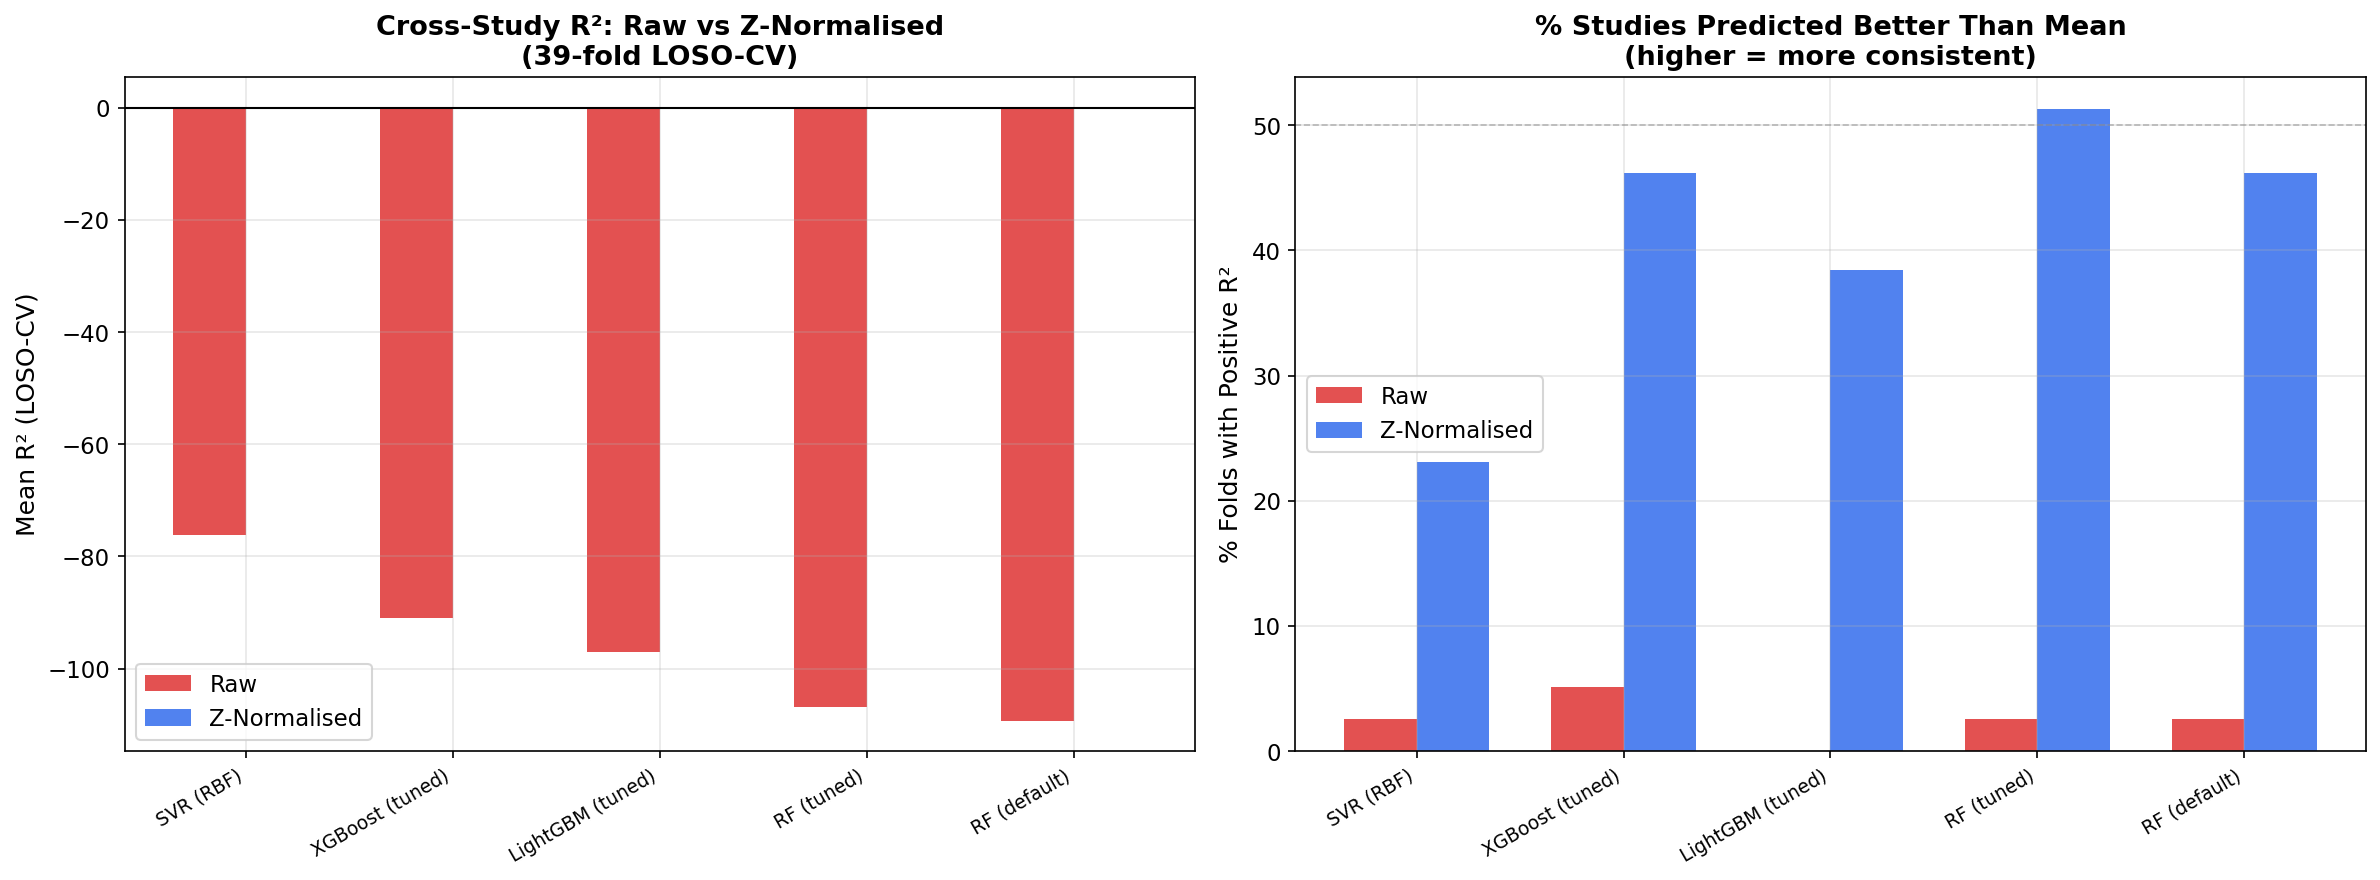

Saved: fig9_raw_vs_znorm_loso.png


In [17]:
# ============================================================
# 7.3 — Figure: Raw vs Z-Normalised LOSO-CV Comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare pivot data
pivot_data = results_df[results_df['Target'] == 'Particle Size'].copy()

# Left: Mean R² comparison
ax = axes[0]
raw_data = pivot_data[pivot_data['Normalised'] == 'Raw'].set_index('Model')['Mean_R2']
znorm_data = pivot_data[pivot_data['Normalised'] == 'Z-Normalised'].set_index('Model')['Mean_R2']

# Get all model names present in either
all_models = list(dict.fromkeys(
    list(raw_data.index) + list(znorm_data.index)
))
x_pos = np.arange(len(all_models))
width = 0.35

bars1 = ax.bar(x_pos - width/2,
               [raw_data.get(m, 0) for m in all_models],
               width, label='Raw', color=COLORS['secondary'], alpha=0.8)
bars2 = ax.bar(x_pos + width/2,
               [znorm_data.get(m, 0) for m in all_models],
               width, label='Z-Normalised', color=COLORS['primary'], alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(all_models, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean R² (LOSO-CV)')
ax.set_title('Cross-Study R²: Raw vs Z-Normalised\n(39-fold LOSO-CV)', fontweight='bold')
ax.legend()
ax.axhline(0, color='black', linewidth=1, linestyle='-')

# Right: % positive folds
ax = axes[1]
raw_pct = pivot_data[pivot_data['Normalised'] == 'Raw'].set_index('Model')['Pct_Positive_R2']
znorm_pct = pivot_data[pivot_data['Normalised'] == 'Z-Normalised'].set_index('Model')['Pct_Positive_R2']

bars1 = ax.bar(x_pos - width/2,
               [raw_pct.get(m, 0) for m in all_models],
               width, label='Raw', color=COLORS['secondary'], alpha=0.8)
bars2 = ax.bar(x_pos + width/2,
               [znorm_pct.get(m, 0) for m in all_models],
               width, label='Z-Normalised', color=COLORS['primary'], alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(all_models, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('% Folds with Positive R²')
ax.set_title('% Studies Predicted Better Than Mean\n(higher = more consistent)', fontweight='bold')
ax.legend()
ax.axhline(50, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig9_raw_vs_znorm_loso.png', bbox_inches='tight')
plt.show()
print('Saved: fig9_raw_vs_znorm_loso.png')

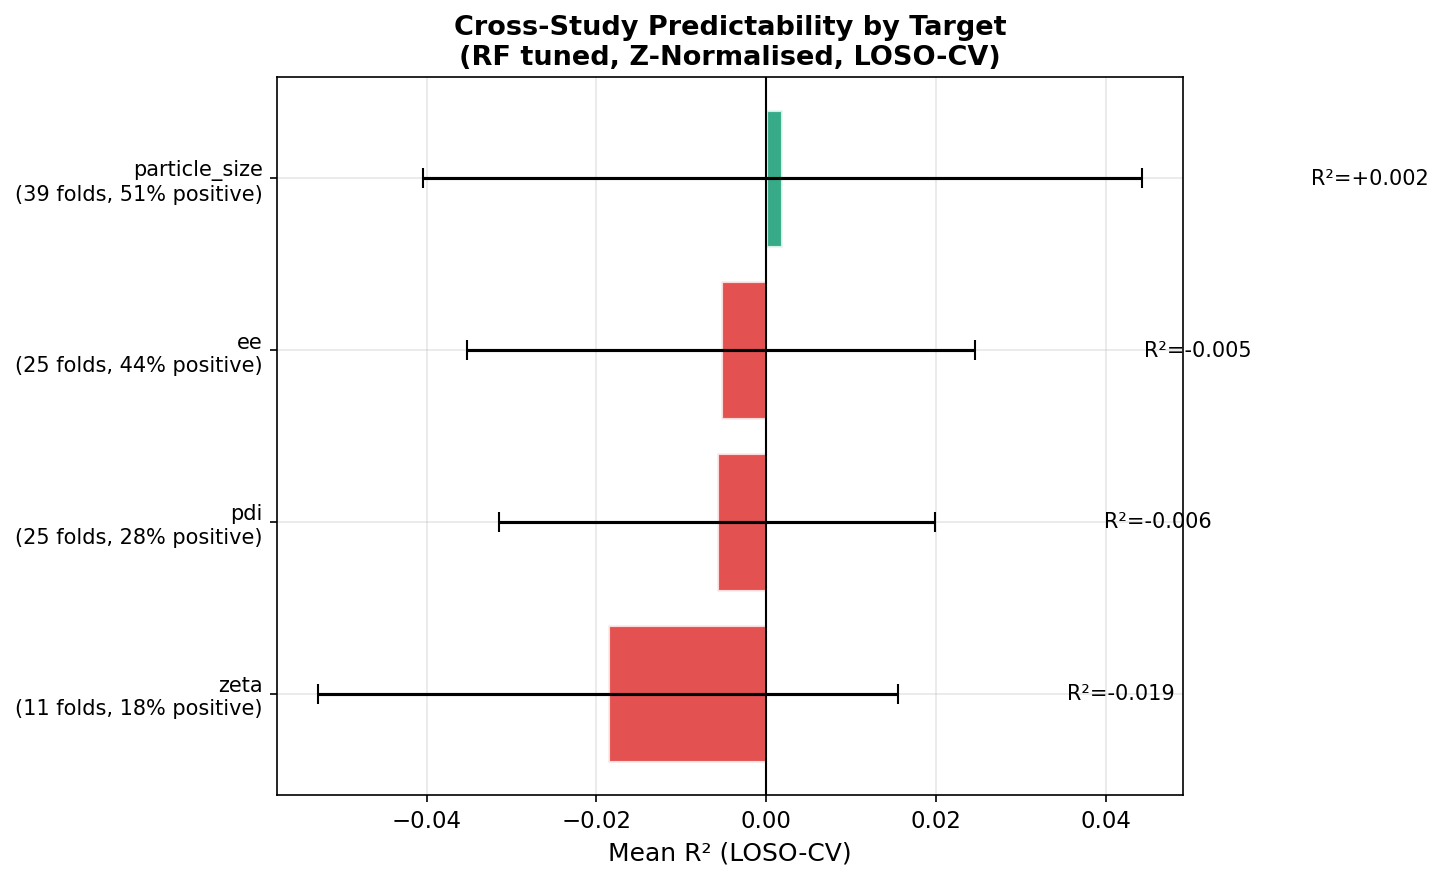

Saved: fig10_multi_target_loso.png


In [18]:
# ============================================================
# 7.4 — Multi-Target LOSO Summary Figure
# ============================================================

if len(mt_loso_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    targets_sorted = mt_loso_df.sort_values('Mean_R2', ascending=True)
    colors_mt = [COLORS['tertiary'] if r > 0 else COLORS['secondary']
                 for r in targets_sorted['Mean_R2']]
    
    bars = ax.barh(range(len(targets_sorted)), targets_sorted['Mean_R2'],
                   xerr=targets_sorted['Std_R2'], color=colors_mt,
                   alpha=0.8, capsize=5, edgecolor='white', linewidth=1.5)
    
    ax.set_yticks(range(len(targets_sorted)))
    ylabels = [f"{row['Target']}\n({row['N_folds']} folds, "
               f"{row['Pct_Positive_R2']:.0f}% positive)"
               for _, row in targets_sorted.iterrows()]
    ax.set_yticklabels(ylabels, fontsize=10)
    ax.set_xlabel('Mean R² (LOSO-CV)', fontsize=12)
    ax.set_title('Cross-Study Predictability by Target\n'
                 '(RF tuned, Z-Normalised, LOSO-CV)', fontweight='bold')
    ax.axvline(0, color='black', linewidth=1)
    
    # Annotate R² values
    for i, (_, row) in enumerate(targets_sorted.iterrows()):
        ax.text(row['Mean_R2'] + row['Std_R2'] + 0.02, i,
                f"R²={row['Mean_R2']:+.3f}", va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'fig10_multi_target_loso.png', bbox_inches='tight')
    plt.show()
    print('Saved: fig10_multi_target_loso.png')

In [19]:
# ============================================================
# 7.5 — Save All Outputs
# ============================================================

# Save comprehensive fold-level details
fold_rows = []
for label, folds in all_fold_details.items():
    for f in folds:
        f_copy = f.copy()
        f_copy['Configuration'] = label
        fold_rows.append(f_copy)

fold_detail_df = pd.DataFrame(fold_rows)
fold_detail_df.to_csv(OUTPUT_DIR / 'phase2a_fold_details.csv', index=False)

print('ALL OUTPUTS SAVED:')
print(f'  phase2a_loso_results.csv        — Master summary table')
print(f'  phase2a_fold_details.csv         — Per-fold details (all configs)')
print(f'  multi_target_loso_znorm.csv      — Multi-target LOSO results')
print(f'  best_hyperparameters.json        — Optuna best params')
print(f'  figures/fig7_study_normalisation  — Normalisation visualisation')
print(f'  figures/fig8_loso_per_study       — Per-study R² breakdown')
print(f'  figures/fig9_raw_vs_znorm_loso    — Raw vs Z-Norm comparison')
print(f'  figures/fig10_multi_target_loso   — Multi-target summary')

ALL OUTPUTS SAVED:
  phase2a_loso_results.csv        — Master summary table
  phase2a_fold_details.csv         — Per-fold details (all configs)
  multi_target_loso_znorm.csv      — Multi-target LOSO results
  best_hyperparameters.json        — Optuna best params
  figures/fig7_study_normalisation  — Normalisation visualisation
  figures/fig8_loso_per_study       — Per-study R² breakdown
  figures/fig9_raw_vs_znorm_loso    — Raw vs Z-Norm comparison
  figures/fig10_multi_target_loso   — Multi-target summary


---
## Summary & Key Takeaways

### What Phase 2A established:
1. **Study-level Z-normalisation** — transforms the prediction task from predicting absolute values to predicting relative deviations within a study
2. **39-fold LOSO-CV** — the honest benchmark, far more rigorous than Phase 1's 2-study holdout
3. **Optuna-tuned baselines** — ensures the comparison with deep learning is fair
4. **Study-conditioned features** — tests whether explicit lab context helps
5. **Multi-target landscape** — which properties are cross-study predictable

### What to look for in the results:
- If Z-normalised R² is positive → normalisation fixed the batch effect problem
- If study-conditioned features help → the model benefits from lab context
- If some targets are easier than others → informs which predictions to highlight

### Next: Phase 2B — GNN Encoder + Study Conditioning
- D-MPNN for ionizable lipid molecular graphs
- Cross-component attention between all 4 lipid types
- Learnable study embeddings
- Multi-task prediction across all targets simultaneously